<a href="https://colab.research.google.com/github/astridcast10/28-07-2026-RECICLAJE_PRUEBA1/blob/main/Computacion_Nube_Reciclaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio #1 - Sistema con IA para clasificación de reciclaje

Entrenar un modelo con las clases:

- cardboard
- glass
- metal
- paper
- plastic
- trash

Al final guardará el modelo y las clases para usarlo en Streamlit

# Paso 1.  Instalar dependencias

In [1]:
!pip install tensorflow numpy pillow matplotlib

In [2]:
!pip install kagglehub

In [3]:
from kagglehub import dataset_download
dataset_path = dataset_download("saumyamohandas/garbage-classification-image-dataset")
print("Ruta del dataset:", dataset_path)

Using Colab cache for faster access to the 'garbage-classification-image-dataset' dataset.
Ruta del dataset: /kaggle/input/garbage-classification-image-dataset


In [4]:
import os

for folder in os.listdir(dataset_path):
  print(folder)

dataset


In [5]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)

Found 2972 files belonging to 1 classes.
['dataset']


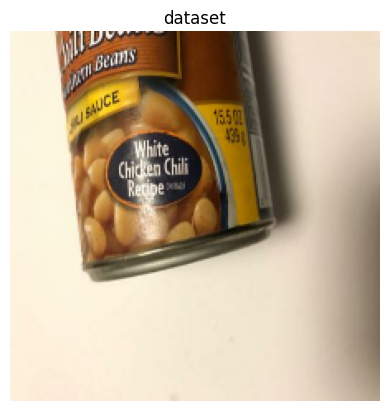

In [6]:
import matplotlib.pyplot as plt
for images, labels in train_ds.take(1):
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(class_names[labels[0]])
    plt.axis("off")

# Paso 2. Importar librerías

In [7]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

## Paso 3. Ajustar la ruta del dataset

La carpeta del dataset debe verse así:

```
garbage-classification/
    cardboard/
    glass/
    metal/
    paper/
    plastic/
    trash/
```

# Paso 4. Cargar imágenes

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
# Define DATA_DIR el path de kagglehub download
DATA_DIR = os.path.join(dataset_path, 'dataset')

train_data_path = os.path.join(DATA_DIR, 'Training')
val_data_path = os.path.join(DATA_DIR, 'Testing')
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_path,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_data_path,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
class_names = train_ds.class_names
print("Clases detectadas:", class_names)

Found 2508 files belonging to 6 classes.
Found 464 files belonging to 6 classes.
Clases detectadas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# Paso 5. Ver algunas imágenes

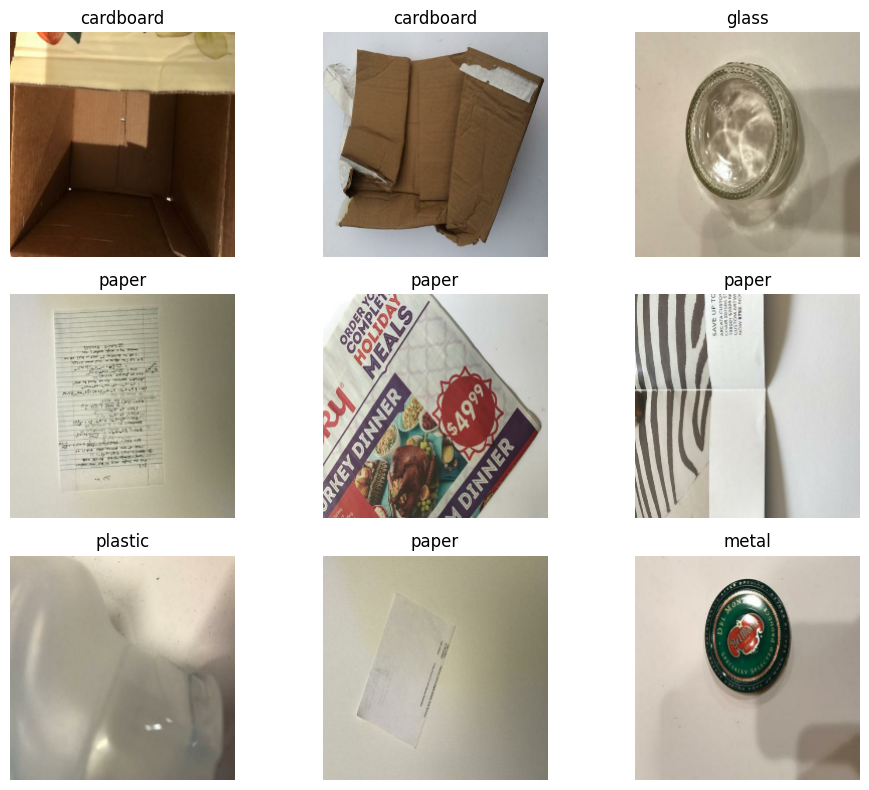

In [9]:

plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

# Paso 6. Preparar el dataset

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

In [11]:

#Crear el modelo MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Paso 8.Repasar una vez EPOCH = 1


In [12]:
EPOCHS = 1

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.5853 - loss: 1.1310 - val_accuracy: 0.7198 - val_loss: 0.7858


## Paso 9. Evaluar

In [13]:
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

Loss: 0.7858
Accuracy: 0.7198


## Paso 10. Guardar el modelo

In [14]:
OUTPUT_DIR = Path("modelo_reciclaje_mobilenet")
OUTPUT_DIR.mkdir(exist_ok=True)
model.save(OUTPUT_DIR / "waste_mobilenet.h5")
#(HDF5- Hierarchical Data Format version 5)
model.save(OUTPUT_DIR / "waste_mobilenet.keras")
with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)
print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.h5")
print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.keras")
print("Clases guardadas en:", OUTPUT_DIR / "class_names.json")

Modelo guardado en: modelo_reciclaje_mobilenet/waste_mobilenet.h5
Modelo guardado en: modelo_reciclaje_mobilenet/waste_mobilenet.keras
Clases guardadas en: modelo_reciclaje_mobilenet/class_names.json


--- Predicciones Top 3 ---
Cartón: 42.56%
Plástico: 20.66%
Papel: 15.28%


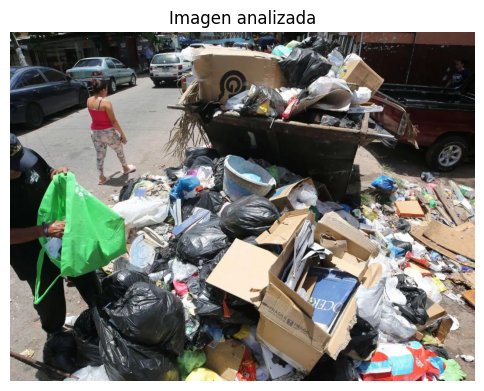

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Definición de etiquetas en español
LABELS_ES = {
    "cardboard": "Cartón",
    "glass": "Vidrio",
    "metal": "Metal",
    "paper": "Papel",
    "plastic": "Plástico",
    "trash": "Basura",
}

# 2. Función de predicción
def predict_image(img_path_param):
    img = Image.open(img_path_param).convert("RGB").resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    preds = model.predict(arr, verbose=0)[0]
    top3_idx = np.argsort(preds)[-3:][::-1]

    print("--- Predicciones Top 3 ---")
    for idx in top3_idx:
        raw = class_names[idx]
        print(f"{LABELS_ES.get(raw, raw)}: {preds[idx]*100:.2f}%")

    return class_names[np.argmax(preds)]

# 3. Ruta directa al archivo cargado en Colab
example_img_path = "desecho.jpg"

# 4. Verificación y ejecución
if os.path.exists(example_img_path):
    predict_image(example_img_path)

    # Mostrar la imagen
    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(example_img_path))
    plt.title("Imagen analizada")
    plt.axis("off")
    plt.show()
else:
    print(f"No se encuentra '{example_img_path}' en el entorno.")
    print("Revisa en el panel izquierdo si la extensión es .jpg, .png o .jpeg")